In [1]:
from dune.grid import cartesianDomain
from dune.alugrid import aluConformGrid as leafGridView
from dune.fem.space import lagrange
import dune
from dune import fem
import numpy as np
import ufl
#from tqdm import tqdm
from matplotlib import pyplot as plt
import pygmsh
mu  = dune.ufl.Constant(1, "mu")
rho = dune.ufl.Constant(1, "rho")
dt = 0.02# dune.ufl.Constant(0.02, "dt")


In [2]:
class NavierStokesSolver:
    def __init__(self, gridView, order, mu, rho, dt):
        self.gridView = gridView
        self.order = order
        self.mu = mu
        self.rho = rho
        self.dt = dune.ufl.Constant(dt, "dt")
        self.t = dune.ufl.Constant(0, name="time")
        self.init()

    def init(self):
        self.V_space = lagrange(self.gridView, order=self.order, dimRange=self.gridView.dimension) # p1Bubble als alternative
    # pressure space
        self.P_space = lagrange(self.gridView, order=self.order-1)
        self.compositeTaylorHoodSpace = fem.space.composite(self.V_space, self.P_space, components=["velocity", "pressure"])

        self.U = ufl.TrialFunction(self.compositeTaylorHoodSpace)
        self.V = ufl.TestFunction(self.compositeTaylorHoodSpace)
        self.x = ufl.SpatialCoordinate(self.compositeTaylorHoodSpace)
        self.n = ufl.FacetNormal(self.compositeTaylorHoodSpace)
        self.u = ufl.as_vector([self.U[0], self.U[1]])
        self.v = ufl.as_vector([self.V[0], self.V[1]])
        self.p = self.U[self.gridView.dimension]
        self.q = self.V[self.gridView.dimension]

        self.f = dune.ufl.Constant((0, 0), "f")
        self.gridView.plot()
        self.composite_solution = self.compositeTaylorHoodSpace.function(name="solution")
        self.u_old = self.V_space.function(name="u_old")
        self.p_old = self.P_space.function(name="p_old")
        self.indices_split = self.u_old.as_numpy.shape[0]
        
        self.exact_u = dune.fem.function.gridFunction(4 * self.x[1] * (1 - self.x[1]),gridView = self.gridView)
        self.exact_p = dune.fem.function.gridFunction(8*(1-self.x[0]),gridView=self.gridView)
        #self.exact_u = self.V_space.interpolate(self.exact_u)
        #self.exact_p = self.P_space.interpolate(self.exact_p)
    
    def generate_navier_stokes_schemes(self, velocity_boundary_condition, pressure_boundary_condition, neumann_boundary_form):
        self.epsilon = lambda w:  1/2*(ufl.nabla_grad(w) + ufl.nabla_grad(w).T)
        self.sigma = -self.p*ufl.Identity(self.gridView.dimension) + 2*self.mu*self.epsilon(self.u)
        step_one_form = (
        rho * ufl.dot((self.u - self.u_old) / self.dt,self. v) * ufl.dx
        + ufl.inner(self.sigma, self.epsilon(self.v)) * ufl.dx
        - ufl.inner(self.f, self.v) * ufl.dx
        + self.rho * ufl.inner(ufl.dot(self.u_old, ufl.nabla_grad(self.u_old)), self.v) * ufl.dx 
    )
        
        step_one_form -= neumann_boundary_form

        step_two_form = ufl.dot(ufl.grad(self.p), ufl.grad(self.q)) * ufl.dx - (ufl.dot(ufl.grad(self.p_old),ufl.grad(self.q))- rho/dt * ufl.div(self.u_old) * self.q) * ufl.dx

        step_three_form = ufl.inner(self.u,self.v) * ufl.dx - (ufl.inner(self.u_old,self.v) - self.dt *ufl.inner(ufl.grad(self.p-self.p_old),self.v))* ufl.dx

        self.step_one_scheme = fem.scheme.galerkin([step_one_form == 0, *velocity_boundary_condition],solver="gmres")
        self.step_two_scheme = fem.scheme.galerkin([step_two_form == 0, *pressure_boundary_condition], solver="gmres")
        self.step_three_scheme = fem.scheme.galerkin([step_three_form == 0, *velocity_boundary_condition], solver="gmres")

    def perform_one_step(self):
        self.step_one_scheme.solve(target=self.composite_solution)
        self.u_old.as_numpy[:] = self.composite_solution.as_numpy[:self.indices_split]
        self.step_two_scheme.solve(target=self.composite_solution)
        self.step_two_scheme.setConstraints(self.composite_solution)
        self.p_old.as_numpy[:] = self.composite_solution.as_numpy[self.indices_split:]
        self.step_three_scheme.solve(target=self.composite_solution)
        self.u_old.as_numpy[:] = self.composite_solution.as_numpy[:self.indices_split]
        
    def integrate(self, endTime, time_between_plots = None):
        # velocity_history = []
        # pressure_history = []
        error_u_list = []
        error_p_list = []
        next_plot_time = 0
        while self.t.value < endTime:
            self.t.value += self.dt.value
            self.perform_one_step()

            error_u_loc = ufl.dot(self.composite_solution[0] - self.exact_u, self.composite_solution[0] - self.exact_u)
            error_u = np.sqrt(fem.integrate(error_u_loc, self.gridView, order=5) )
            error_u_list.append(error_u)
            
            error_p_loc = ufl.dot(self.composite_solution[2] - self.exact_p, self.composite_solution[2] - self.exact_p)
            error_p = np.sqrt(fem.integrate(error_p_loc, self.gridView, order=5) )
            error_p_list.append(error_p)
            
            # velocity_history.append(self.composite_solution.as_numpy[:self.indices_split].copy())
            # pressure_history.append(self.composite_solution.as_numpy[self.indices_split:].copy())
            if time_between_plots is not None and self.t.value >= next_plot_time:
                next_plot_time += time_between_plots
                self.composite_solution[0].plot()
                self.composite_solution[1].plot()
                self.composite_solution[2].plot()
        return error_u_list, error_p_list # velocity_history, pressure_history

    def adapt(self):
        curl = ufl.curl(ufl.as_vector([self.composite_solution[0], self.composite_solution[1]]))
        curl = ufl.inner(curl, curl)
        curl = self.element_storage.interpolate(curl, name="curl")
        min_curl = comm.sum(np.min(curl.as_numpy))
        max_curl = comm.sum(np.max(curl.as_numpy))
        if max_curl > min_curl:
            curl.as_numpy[:] -= min_curl
            curl.as_numpy[:] /= (max_curl - min_curl)
        fem.mark(curl,refineTolerance=0.75, coarsenTolerance=0.25, maxLevel=self.max_refinement_level)
        fem.adapt([self.composite_solution, self.u_old, self.p_old])
        self.indices_split = self.u_old.as_numpy.shape[0]


## Test

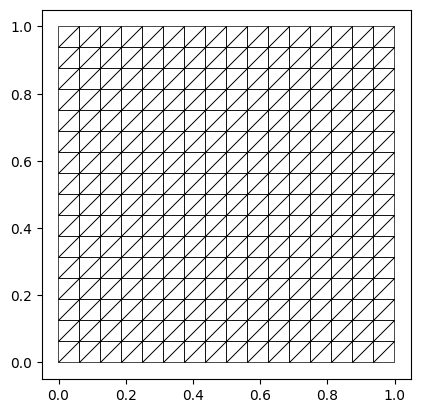

In [9]:
domain = cartesianDomain([0,0], [1,1], [16,16])
gridView = leafGridView(domain)
order = 2
solver = NavierStokesSolver(gridView, order, mu, rho, dt)
no_slip_bottom = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] < 1e-10)
no_slip_top = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] > 1-1e-10)
pressure_dirichlet_left = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 8.0], solver.x[0] < 1e-10)
pressure_dirichlet_right = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 0.0], solver.x[0] > 1-1e-10)
neumann_boundary_form = ufl.inner(
        ufl.dot(ufl.nabla_grad(solver.u), solver.n)*solver.mu - solver.p * solver.n, solver.v
    ) * (ufl.conditional(ufl.lt(solver.x[0], 1e-10), 1, 0) + ufl.conditional(ufl.gt(solver.x[0], 1 - 1e-10), 1, 0)) * ufl.ds
solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top], [pressure_dirichlet_left, pressure_dirichlet_right], neumann_boundary_form)

# exact_u = dune.fem.function.gridFunction([4 * solver.x[1] * (1 - solver.x[1]),0],gridView = gridView)
# exact_p = dune.fem.function.gridFunction(8*(1-solver.x[0]),gridView)
# exact_u = solver.V_space.interpolate(exact_u)
# exact_p = solver.P_space.interpolate(exact_p)

# exact_u.plot()
# exact_p.plot()

In [10]:
t_end = 10
velocity_history, pressure_history = solver.integrate(t_end)
velocity_history = np.array(velocity_history)
pressure_history = np.array(pressure_history)

DUNE-INFO: Compiling UFLLocalFunction (new)
DUNE-INFO: Compiling UFLLocalFunction (new)


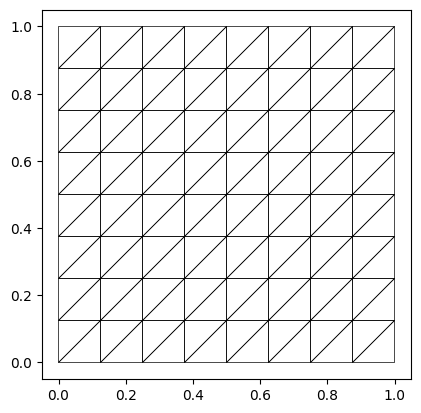

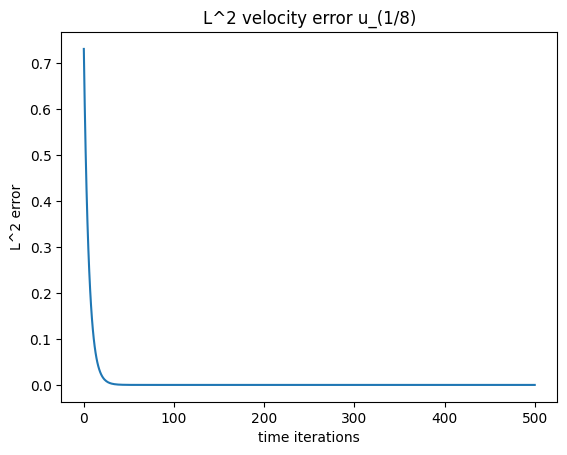

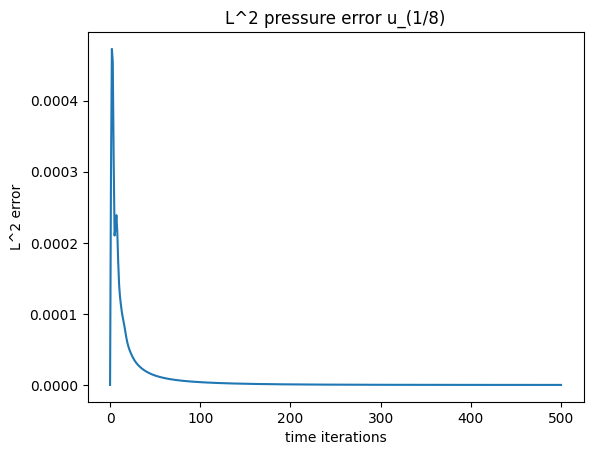

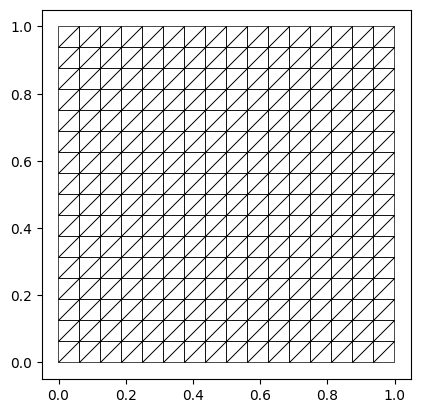

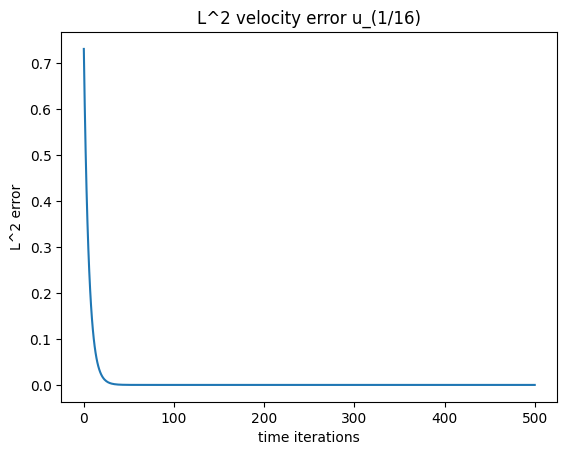

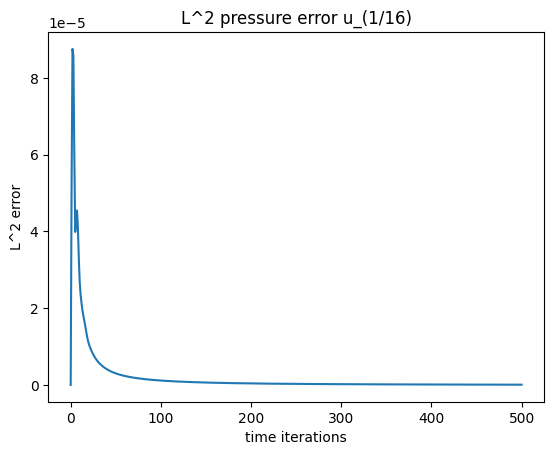

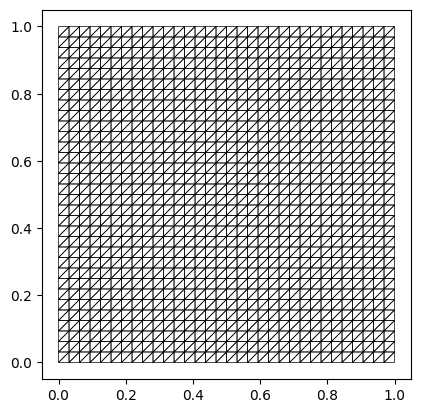

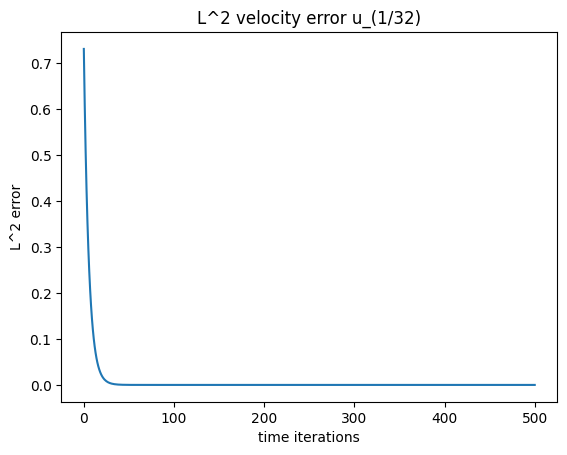

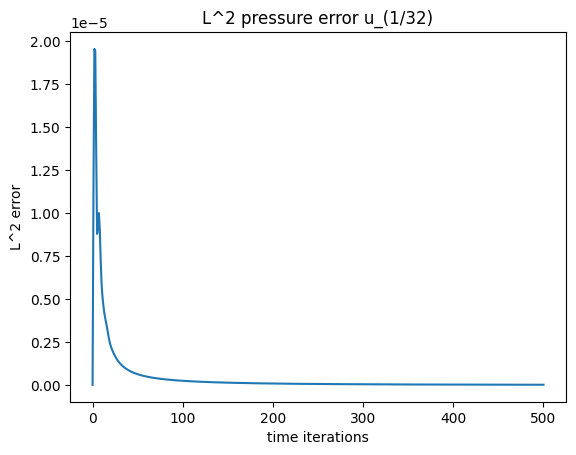

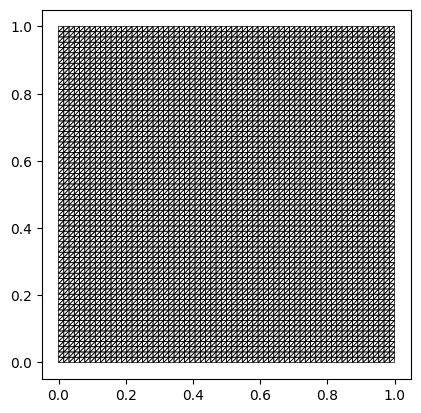

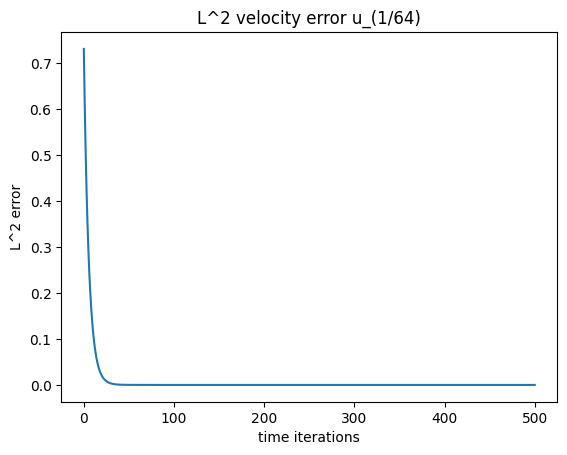

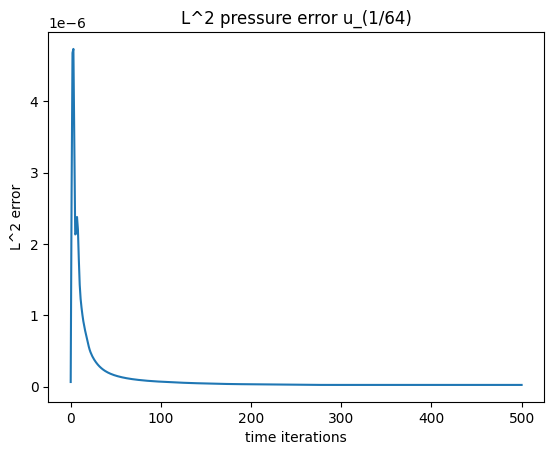

In [21]:
for i in range(3,7):
    domain = cartesianDomain([0,0], [1,1], [2**i,2**i])
    gridView = leafGridView(domain)
    order = 2
    solver = NavierStokesSolver(gridView, order, mu, rho, dt)
    no_slip_bottom = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] < 1e-10)
    no_slip_top = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] > 1-1e-10)
    pressure_dirichlet_left = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 8.0], solver.x[0] < 1e-10)
    pressure_dirichlet_right = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 0.0], solver.x[0] > 1-1e-10)
    neumann_boundary_form = ufl.inner(
            ufl.dot(ufl.nabla_grad(solver.u), solver.n)*solver.mu - solver.p * solver.n, solver.v
        ) * (ufl.conditional(ufl.lt(solver.x[0], 1e-10), 1, 0) + ufl.conditional(ufl.gt(solver.x[0], 1 - 1e-10), 1, 0)) * ufl.ds
    solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top], [pressure_dirichlet_left, pressure_dirichlet_right], neumann_boundary_form)
    t_end = 10
    velocity_error, pressure_error = solver.integrate(t_end)
    velocity_error = np.array(velocity_error)
    pressure_error = np.array(pressure_error)
    print('err<10^-5: ',np.where(velocity_error<10**(-5)))
    print('err<10^-6: ',np.where(velocity_error<10**(-6)))
    print('err<10^-7: ',np.where(velocity_error<10**(-7)))
    print('err<10^-8: ',np.where(velocity_error<10**(-8)))
    plt.title('L^2 velocity error u_(1/{})'.format(2**i))
    plt.plot(velocity_error)
    plt.xlabel('time iterations')
    plt.ylabel('L^2 error')
    plt.savefig('velo_l2_err_{}.png'.format(i),dpi=300)
    plt.show()
    
    plt.title('L^2 pressure error u_(1/{})'.format(2**i))
    plt.plot(pressure_error)
    plt.xlabel('time iterations')
    plt.ylabel('L^2 error')
    plt.savefig('pres_l2_err_{}.png'.format(i),dpi=300)
    plt.show()

In [ ]:
l_2_error = np.linalg.norm(velocity_history - exact_u.as_numpy, axis=1)
mean_velocity = np.mean(velocity_history, axis=1)
std_velocity = np.std(velocity_history, axis=1)
mean_pressure = np.mean(pressure_history, axis=1)
std_pressure = np.std(pressure_history, axis=1)
plt.loglog(l_2_error)
plt.xlabel("iterations")
plt.ylabel("L2 error")
plt.title("L2 error of velocity")
plt.figure()
plt.loglog(mean_velocity, label="mean velocity")
plt.loglog(std_velocity, label="std velocity")
plt.loglog(mean_pressure, label="mean pressure")
plt.loglog(std_pressure, label="std pressure")
plt.xlabel("iterations")
plt.legend()

Number of elements:  162


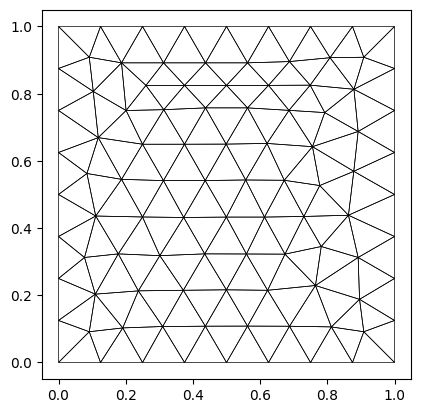

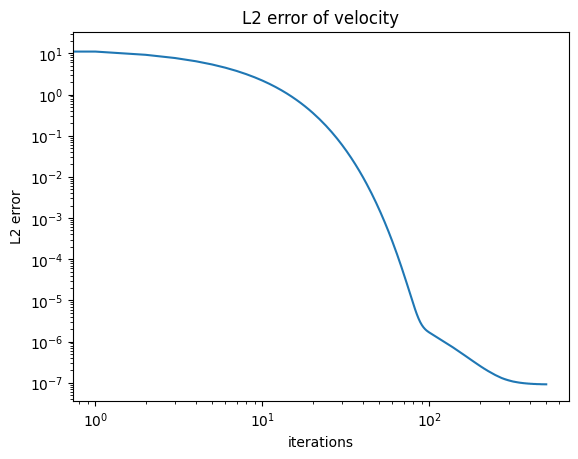

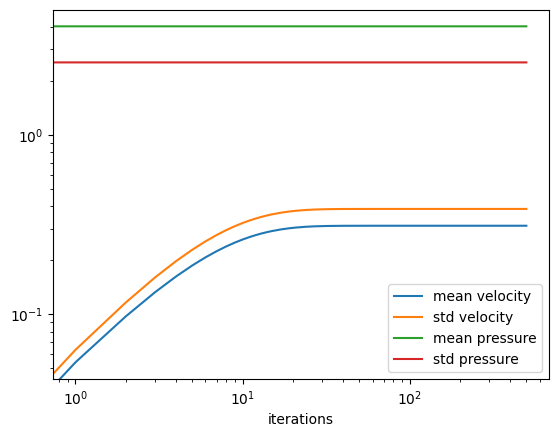

In [5]:
order = 2
t_end = 10
with pygmsh.occ.Geometry() as geom:
    # add rectangle with length 1 in x and 1 in y direction.
    L, H = 1. , 1.
    rectangle = geom.add_rectangle([0,0,0], L, H)
    mesh = geom.generate_mesh()
    points, cells = mesh.points, mesh.cells_dict
    # convert to dictionary understood by DUNE
    domain = {"vertices": points[:,:2].astype(float),
              "simplices": cells["triangle"].astype(int)}
    print("Number of elements: ", len(domain["simplices"]))

triangular_grid = leafGridView(domain, dimgrid=2)
triangular_solver = NavierStokesSolver(triangular_grid, order, mu, rho, dt)
neumann_boundary_form = ufl.inner(
        ufl.dot(ufl.nabla_grad(triangular_solver.u), triangular_solver.n)*triangular_solver.mu - triangular_solver.p * triangular_solver.n, triangular_solver.v
    ) * (ufl.conditional(ufl.lt(triangular_solver.x[0], 1e-10), 1, 0) + ufl.conditional(ufl.gt(triangular_solver.x[0], 1 - 1e-10), 1, 0)) * ufl.ds
no_slip_bottom = dune.ufl.DirichletBC(triangular_solver.compositeTaylorHoodSpace, [0,0,None], triangular_solver.x[1] < 1e-10)
no_slip_top = dune.ufl.DirichletBC(triangular_solver.compositeTaylorHoodSpace, [0,0,None], triangular_solver.x[1] > 1-1e-10)
pressure_dirichlet_left = dune.ufl.DirichletBC(triangular_solver.compositeTaylorHoodSpace, [None, None, 8.0], triangular_solver.x[0] < 1e-10)
pressure_dirichlet_right = dune.ufl.DirichletBC(triangular_solver.compositeTaylorHoodSpace, [None, None, 0.0], triangular_solver.x[0] > 1-1e-10)
triangular_solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top], [pressure_dirichlet_left, pressure_dirichlet_right], neumann_boundary_form)
exact_u = dune.fem.function.gridFunction([4 * triangular_solver.x[1] * (1 - triangular_solver.x[1]),0],gridView = triangular_grid)
exact_p = dune.fem.function.gridFunction(8*(1-triangular_solver.x[0]),triangular_grid)
exact_u = triangular_solver.V_space.interpolate(exact_u)
exact_p = triangular_solver.P_space.interpolate(exact_p)

velocity_history, pressure_history = triangular_solver.integrate(t_end)
velocity_history = np.array(velocity_history)
pressure_history = np.array(pressure_history)

l_2_error = np.linalg.norm(velocity_history - exact_u.as_numpy, axis=1)
mean_velocity = np.mean(velocity_history, axis=1)
std_velocity = np.std(velocity_history, axis=1)
mean_pressure = np.mean(pressure_history, axis=1)
std_pressure = np.std(pressure_history, axis=1)
plt.loglog(l_2_error)
plt.xlabel("iterations")
plt.ylabel("L2 error")
plt.title("L2 error of velocity")
plt.figure()
plt.loglog(mean_velocity, label="mean velocity")
plt.loglog(std_velocity, label="std velocity")
plt.loglog(mean_pressure, label="mean pressure")
plt.loglog(std_pressure, label="std pressure")
plt.xlabel("iterations")
plt.legend()

In [10]:
from dune.grid import cartesianDomain
from dune.alugrid import aluConformGrid as leafGridView
from dune.fem.space import lagrange
from dune.fem.function import gridFunction
import dune
from dune import fem
import numpy as np
import ufl
from matplotlib import pyplot as plt
import pygmsh
mu  = dune.ufl.Constant(1, "mu")
rho = dune.ufl.Constant(1, "rho")
dt = 0.02

# Error Analysis

In [22]:
class NavierStokesSolver:
    def __init__(self, gridView, order, mu, rho, dt):
        self.gridView = gridView
        self.order = order
        self.mu = mu
        self.rho = rho
        self.dt = dune.ufl.Constant(dt, "dt")
        self.t = dune.ufl.Constant(0, name="time")
        self.init()

    def init(self):
        self.V_space = lagrange(self.gridView, order=self.order, dimRange=self.gridView.dimension) 
        self.P_space = lagrange(self.gridView, order=self.order-1)
        self.compositeTaylorHoodSpace = fem.space.composite(self.V_space, self.P_space, components=["velocity", "pressure"])

        self.U = ufl.TrialFunction(self.compositeTaylorHoodSpace)
        self.V = ufl.TestFunction(self.compositeTaylorHoodSpace)
        self.x = ufl.SpatialCoordinate(self.compositeTaylorHoodSpace)
        self.n = ufl.FacetNormal(self.compositeTaylorHoodSpace)
        self.u = ufl.as_vector([self.U[0], self.U[1]])
        self.v = ufl.as_vector([self.V[0], self.V[1]])
        self.p = self. U[self.gridView.dimension]
        self.q = self.V[self.gridView.dimension]
        
        self.f = dune.ufl.Constant((0, 0), "f")
        self.gridView.plot()
        self.composite_solution = self.compositeTaylorHoodSpace.function(name="solution")
        self.u_old = self.V_space.function(name="u_old")
        self.p_old = self.P_space.function(name="p_old")
        self.indices_split = self.u_old.as_numpy.shape[0]
        self.exact_u = gridFunction(4 * self.x[1] *(1-self.x[1]), name="exact_u", gridView=self.gridView, order=2)
        self.exact_p = gridFunction(8 * (1-self.x[0]), name="exact_p", gridView=self.gridView, order=1)
        
    def generate_navier_stokes_schemes(self, velocity_boundary_condition, pressure_boundary_condition, neumann_boundary_form):
        self.epsilon = lambda w:  1/2*(ufl.nabla_grad(w) + ufl.nabla_grad(w).T)
        self.sigma = -self.p*ufl.Identity(self.gridView.dimension) + 2*self.mu*self.epsilon(self.u)
        step_one_form = (
        rho * ufl.dot((self.u - self.u_old) / self.dt,self. v) * ufl.dx
        + ufl.inner(self.sigma, self.epsilon(self.v)) * ufl.dx
        - ufl.inner(self.f, self.v) * ufl.dx
        + self.rho * ufl.inner(ufl.dot(self.u_old, ufl.nabla_grad(self.u_old)), self.v) * ufl.dx 
    )
        
        step_one_form -= neumann_boundary_form

        step_two_form = ufl.dot(ufl.grad(self.p), ufl.grad(self.q)) * ufl.dx - (ufl.dot(ufl.grad(self.p_old),ufl.grad(self.q))- rho/dt * ufl.div(self.u_old) * self.q) * ufl.dx

        step_three_form = ufl.inner(self.u,self.v) * ufl.dx - (ufl.inner(self.u_old,self.v) - self.dt *ufl.inner(ufl.grad(self.p-self.p_old),self.v))* ufl.dx

        self.step_one_scheme = fem.scheme.galerkin([step_one_form == 0, *velocity_boundary_condition],solver="gmres")
        self.step_two_scheme = fem.scheme.galerkin([step_two_form == 0, *pressure_boundary_condition], solver="gmres")
        self.step_three_scheme = fem.scheme.galerkin([step_three_form == 0, *velocity_boundary_condition], solver="gmres")

    def perform_one_step(self):
        self.step_one_scheme.solve(target=self.composite_solution)
        self.u_old.as_numpy[:] = self.composite_solution.as_numpy[:self.indices_split]
        self.step_two_scheme.solve(target=self.composite_solution)
        self.step_two_scheme.setConstraints(self.composite_solution)
        self.p_old.as_numpy[:] = self.composite_solution.as_numpy[self.indices_split:]
        self.step_three_scheme.solve(target=self.composite_solution)
        self.u_old.as_numpy[:] = self.composite_solution.as_numpy[:self.indices_split]

    def integrate(self, endTime, time_between_plots=None):
        error_u_list= []
        error_p_list= []
        next_plot_time = 0
        
        while self.t.value < endTime:
            self.t.value += self.dt.value
            self.perform_one_step()
            error_u_loc = ufl.dot(self.composite_solution[0] - self.exact_u, self.composite_solution[0] - self.exact_u)
            error_u = np.sqrt(fem.integrate(error_u_loc, self.gridView, order=3) )
            error_u_list.append(error_u)
            
            error_p_loc = ufl.dot(self.composite_solution[2] - self.exact_p, self.composite_solution[2] - self.exact_p)
            error_p = np.sqrt(fem.integrate(error_p_loc, self.gridView, order=3) )
            error_p_list.append(error_p)
            
            if time_between_plots is not None and self.t.value >= next_plot_time:
                next_plot_time += time_between_plots
                self.vtk()
                
        return error_u_list, error_p_list

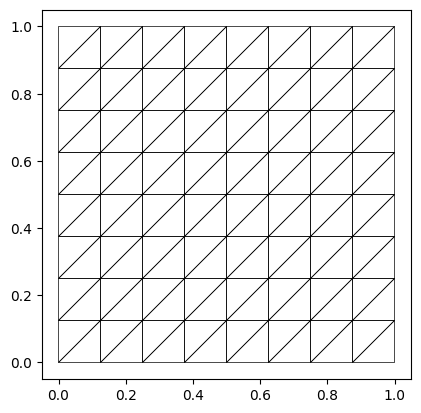

DUNE-INFO: Compiling UFLLocalFunction (new)


In [23]:
domain = cartesianDomain([0,0], [1,1], [8,8])
gridView = leafGridView(domain)
error_v = {}
error_p = {}

for i in range(1,7):
    n_cell = gridView.size(0)
    order = 2
    solver = NavierStokesSolver(gridView, order, mu, rho, 4/n_cell)
    no_slip_bottom = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] < 1e-10)
    no_slip_top = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] > 1-1e-10)
    pressure_dirichlet_left = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 8.0], solver.x[0] < 1e-10)
    pressure_dirichlet_right = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 0.0], solver.x[0] > 1-1e-10)
    neumann_boundary_form = ufl.inner(
            ufl.dot(ufl.nabla_grad(solver.u), solver.n)*solver.mu - solver.p * solver.n, solver.v
        ) * (ufl.conditional(ufl.lt(solver.x[0], 1e-10), 1, 0) + ufl.conditional(ufl.gt(solver.x[0], 1 - 1e-10), 1, 0)) * ufl.ds
    solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top], [pressure_dirichlet_left, pressure_dirichlet_right], neumann_boundary_form)
    t_end = 10
    velocity_error, pressure_error = solver.integrate(t_end)
    velocity_error = np.array(velocity_error)
    pressure_error = np.array(pressure_error)
    error_v[n_cell] = velocity_error
    error_p[n_cell] = pressure_error
    gridView.hierarchicalGrid.globalRefine(1)

In [25]:
for j in error_v.keys():
    print(j,error_v[j][-1])

128 6.8585307128303775e-09


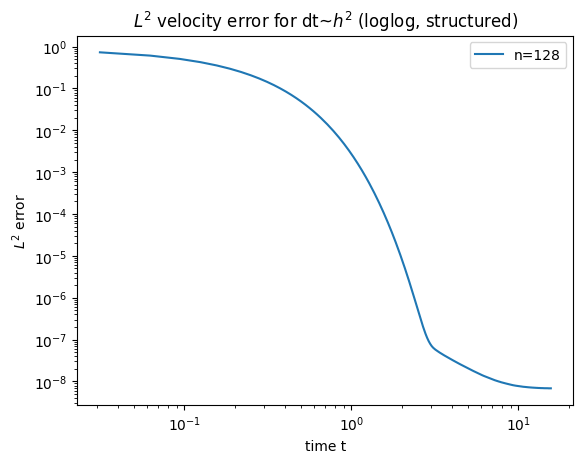

In [26]:
for j in error_v.keys():
    i=1
    plt.loglog([n*4/j for n in range(1,len(error_v[j])+1)],error_v[j], label='n={}'.format(j))
    i+=1
plt.legend()
plt.title('$L^2$ velocity error for dt~$h^2$ (loglog, structured)')
plt.xlabel('time t')
plt.ylabel('$L^2$ error')
plt.show()

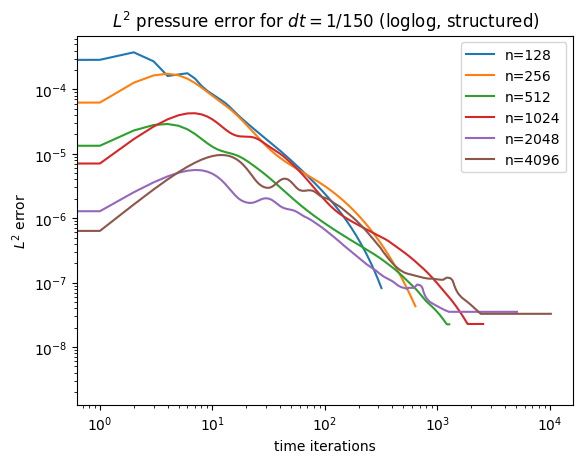

In [80]:
for j in error_p.keys():
    plt.loglog([n*4/j for n in range(1,len(error_v[j])+1)],error_p[j], label='n={}'.format(j))
plt.legend()
plt.title('$L^2$ pressure error for $dt=1/150$ (loglog, structured)')
plt.xlabel('time iterations')
plt.ylabel('$L^2$ error')
plt.show()

Number of elements:  162


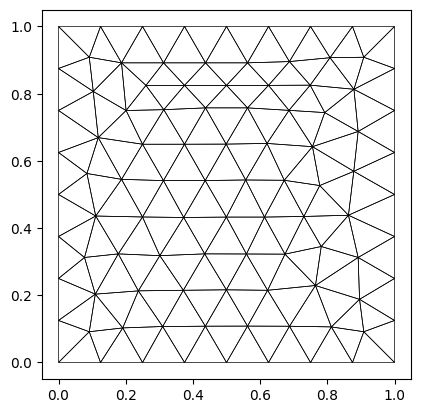

Number of elements:  393


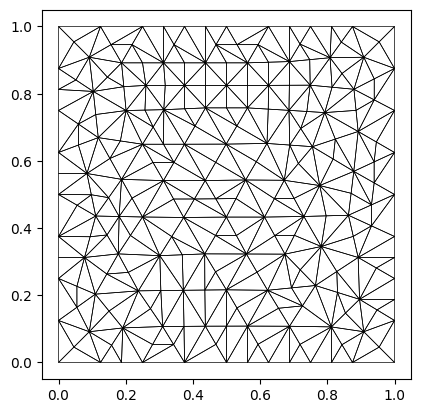

Number of elements:  889


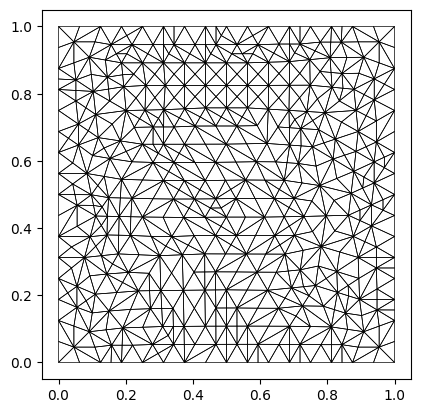

Number of elements:  1937


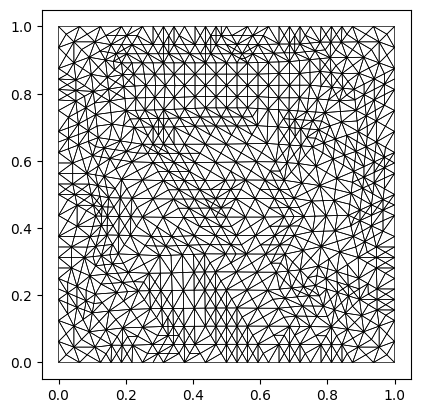

Number of elements:  4129


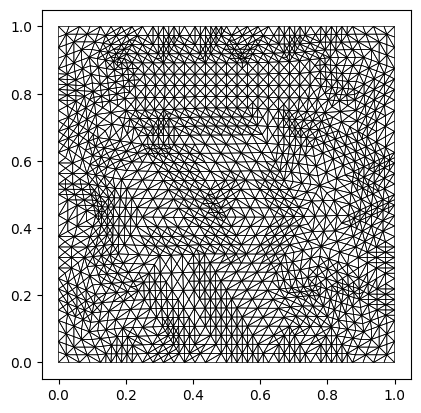

In [5]:
with pygmsh.occ.Geometry() as geom:
    # add rectangle with length 1 in x and 1 in y direction.
    L, H = 1. , 1.
    rectangle = geom.add_rectangle([0,0,0], L, H)
    mesh = geom.generate_mesh()
    points, cells = mesh.points, mesh.cells_dict
    # convert to dictionary understood by DUNE
    domain = {"vertices": points[:,:2].astype(float),
              "simplices": cells["triangle"].astype(int)}
    
error_v = {}
error_p = {}
gridView = leafGridView(domain)
for i in range(1,6):
    n_cell = gridView.size(0)
    print("Number of elements: ", n_cell)
    order = 2
    solver = NavierStokesSolver(gridView, order, mu, rho, 1/100)#3/n_cell)
    no_slip_bottom = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] < 1e-10)
    no_slip_top = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [0,0,None], solver.x[1] > 1-1e-10)
    pressure_dirichlet_left = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 8.0], solver.x[0] < 1e-10)
    pressure_dirichlet_right = dune.ufl.DirichletBC(solver.compositeTaylorHoodSpace, [None, None, 0.0], solver.x[0] > 1-1e-10)
    neumann_boundary_form = ufl.inner(
            ufl.dot(ufl.nabla_grad(solver.u), solver.n)*solver.mu - solver.p * solver.n, solver.v
        ) * (ufl.conditional(ufl.lt(solver.x[0], 1e-10), 1, 0) + ufl.conditional(ufl.gt(solver.x[0], 1 - 1e-10), 1, 0)) * ufl.ds
    solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top], [pressure_dirichlet_left, pressure_dirichlet_right], neumann_boundary_form)
    t_end = 10
    velocity_error, pressure_error = solver.integrate(t_end)
    velocity_error = np.array(velocity_error)
    pressure_error = np.array(pressure_error)
    error_v[n_cell] = velocity_error
    error_p[n_cell] = pressure_error
    
    gridView.hierarchicalGrid.globalRefine(1)

In [6]:
for j in error_v.keys():
    print(j,error_v[j][-1])

162 1.0693828023146908e-08
393 1.2247352483750135e-08
889 4.41918911364969e-09
1937 3.382874371512352e-08
4129 8.355803757260759e-08


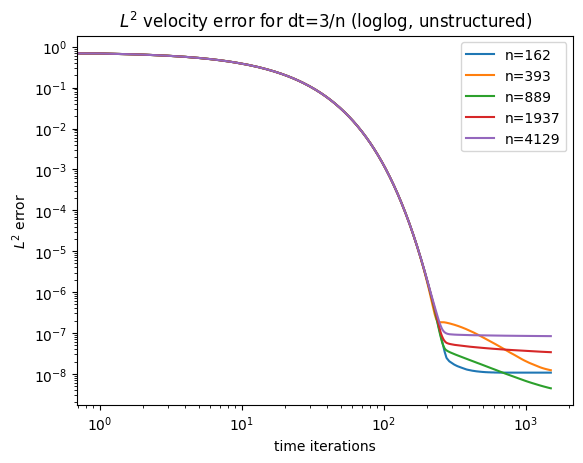

In [8]:
for j in error_v.keys():
    plt.loglog([n*3/j for n in range(1,len(error_v[j])+1)],error_v[j], label='n={}'.format(j))
plt.legend()
plt.title('$L^2$ velocity error for dt=3/n (loglog, unstructured)')
plt.xlabel('time iterations')
plt.ylabel('$L^2$ error')
plt.savefig('L2_loglog_v_unstruc_error_adaptT.png',dpi=300)
plt.show()

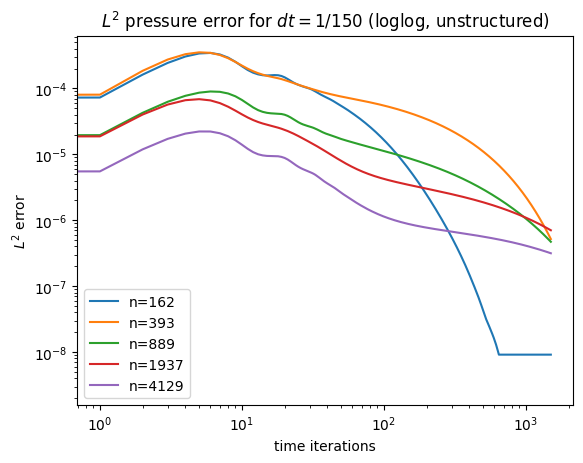

In [9]:
for j in error_p.keys():
    plt.loglog(error_p[j], label='n={}'.format(j))
plt.legend()
plt.title('$L^2$ pressure error for $dt=1/150$ (loglog, unstructured)')
plt.xlabel('time iterations')
plt.ylabel('$L^2$ error')
plt.savefig('L2_loglog_p_unstruc_error150.png',dpi=300)
plt.show()

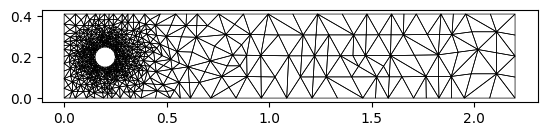

DUNE-INFO: Compiling Integrands (new)
DUNE-INFO: Compiling Integrands (new)


In [9]:
coarse = True
order = 2
L, H = 2.2, 0.41
r = 0.05
#with pygmsh.occ.Geometry() as geom:
    # Domain size
#    L, H = 2.2, 0.41
#    r = 0.05
#    rectangle = geom.add_rectangle([0.0, 0.0, 0.0], L, H)
#    cylinder = geom.add_disk([0.2, 0.2, 0.0], r)
#    domain = geom.boolean_difference([rectangle], [cylinder])
#    mesh = geom.generate_mesh()
#    points, cells = mesh.points, mesh.cells_dict
#    domain = {"vertices": points[:,:2].astype(float),
#              "simplices": cells["triangle"].astype(int)}
with pygmsh.occ.Geometry() as geom:
    radius2 = lambda x , y : (x - 0.2)**2 + (y - 0.2)**2
    outsideSize = 0.25 if coarse else 0.04
    insideSize = lambda x , y : 0.02 + 1.5*radius2 (x, y)
    geom.set_mesh_size_callback(lambda dim, tag, x, y, z, lc: min(insideSize(x,y),outsideSize))
    rectangle = geom.add_rectangle ([0 , 0 , 0 ] , 2.2 , 0.41)
    cylinder = geom.add_disk([0.2, 0.2, 0.0], 0.05)
    geom.boolean_difference(rectangle, cylinder)
    mesh = geom.generate_mesh()
    points, cells = mesh.points, mesh.cells_dict
    # extract dictionary for grid construction
    domain = {"vertices": points [:, :2].astype(float), "simplices": cells["triangle"].astype(int)}
vortex_street_grid = leafGridView(domain, dimgrid=2)
#vortex_street_grid.hierarchicalGrid.globalRefine(2)
mu.value = 1E-3
dt.value = 1E-4
vortex_solver = NavierStokesSolver(vortex_street_grid, order, mu, rho, dt)
no_slip_bottom = dune.ufl.DirichletBC(vortex_solver.compositeTaylorHoodSpace, [0, 0, None], vortex_solver.x[1] < 1e-10)
no_slip_top = dune.ufl.DirichletBC(vortex_solver.compositeTaylorHoodSpace, [0, 0, None], vortex_solver.x[1] > H - 1e-10)
no_slip_cylinder = dune.ufl.DirichletBC(vortex_solver.compositeTaylorHoodSpace, [0, 0, None], ufl.sqrt((vortex_solver.x[0] - 0.2)**2 + (vortex_solver.x[1] - 0.2)**2) < r + 1e-10)

pressure_dirichlet_right = dune.ufl.DirichletBC(vortex_solver.compositeTaylorHoodSpace, [None, None, 0.0], vortex_solver.x[0] > L - 1e-10)
neumann_boundary_form_right = ufl.inner(
        ufl.dot(ufl.nabla_grad(vortex_solver.u), vortex_solver.n)*vortex_solver.mu - vortex_solver.p * vortex_solver.n, vortex_solver.v
    ) * ufl.conditional(ufl.gt(vortex_solver.x[0], L - 1e-10), 1, 0) * ufl.ds
velocity_inflow_boundary = dune.ufl.DirichletBC(vortex_solver.compositeTaylorHoodSpace, [(6 * vortex_solver.x[1]*(H-vortex_solver.x[1]))/np.pow(H,2), 0, None], vortex_solver.x[0] < 1e-10)

vortex_solver.generate_navier_stokes_schemes([no_slip_bottom, no_slip_top, no_slip_cylinder, velocity_inflow_boundary], [pressure_dirichlet_right], neumann_boundary_form_right)

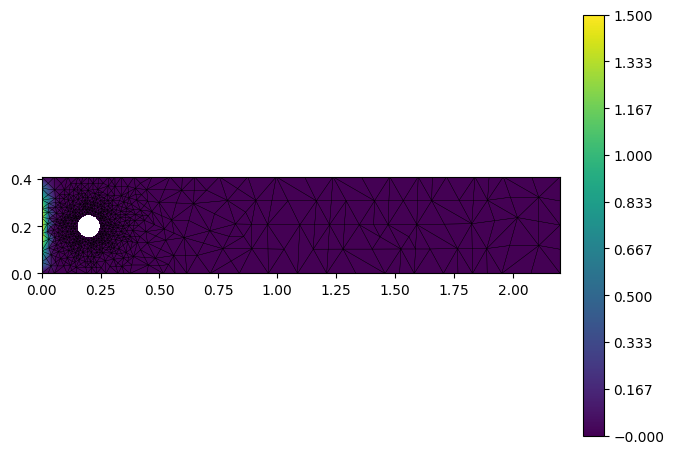

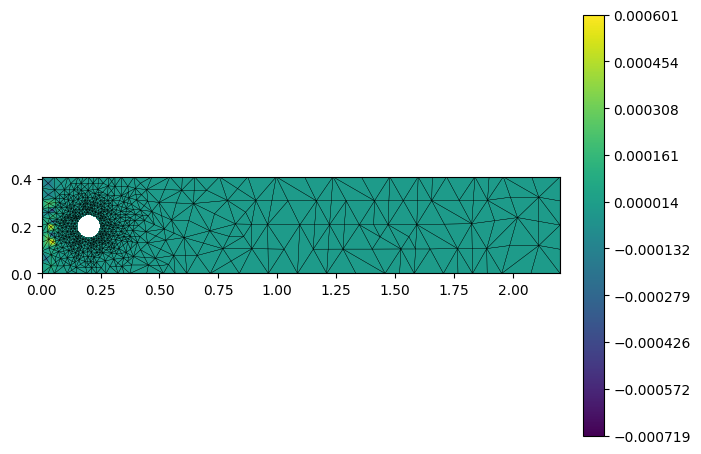

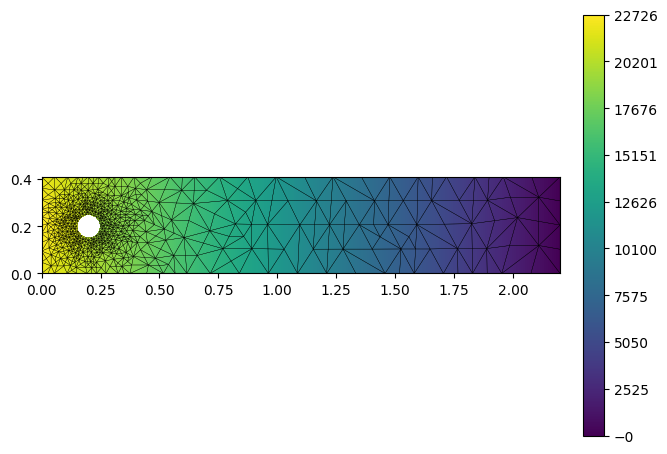

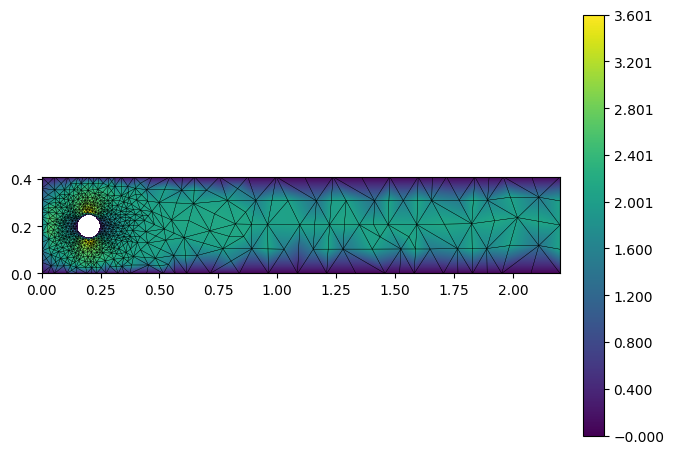

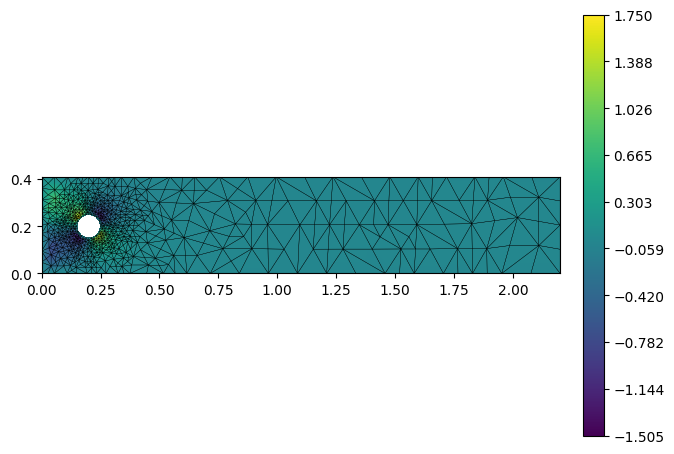

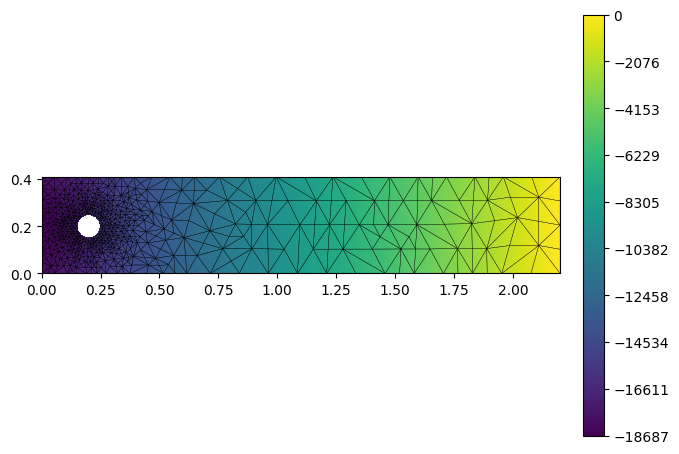

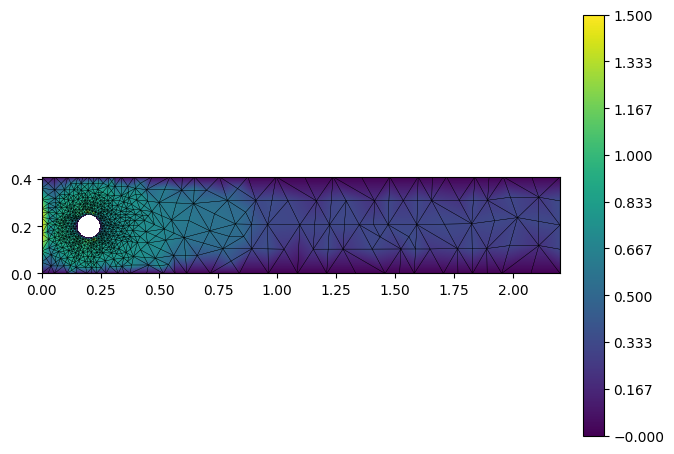

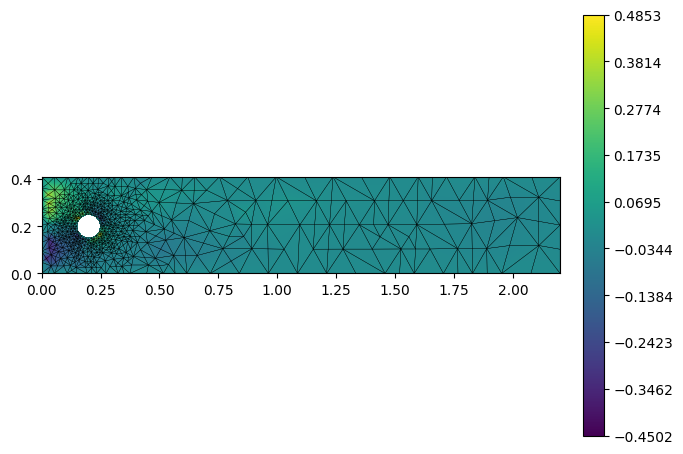

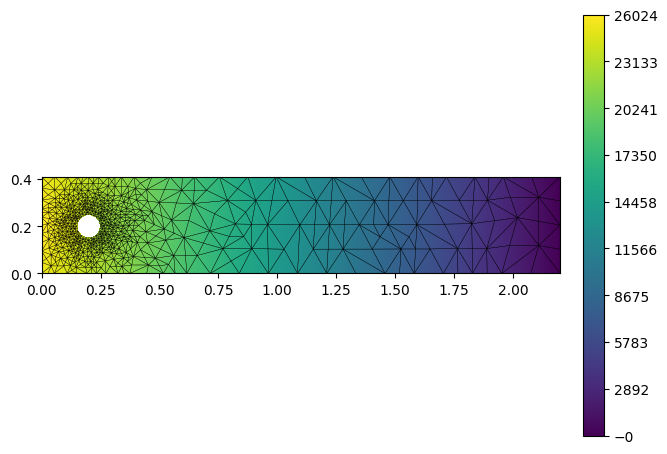

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


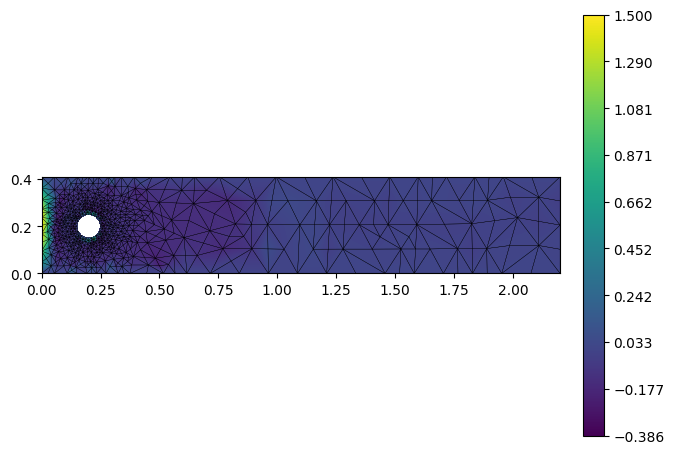

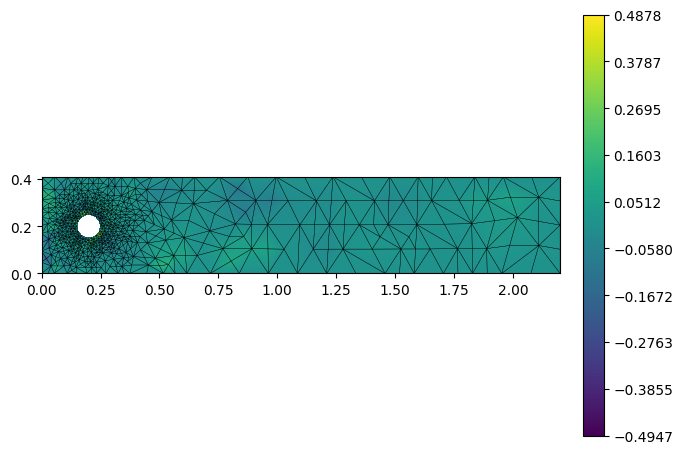

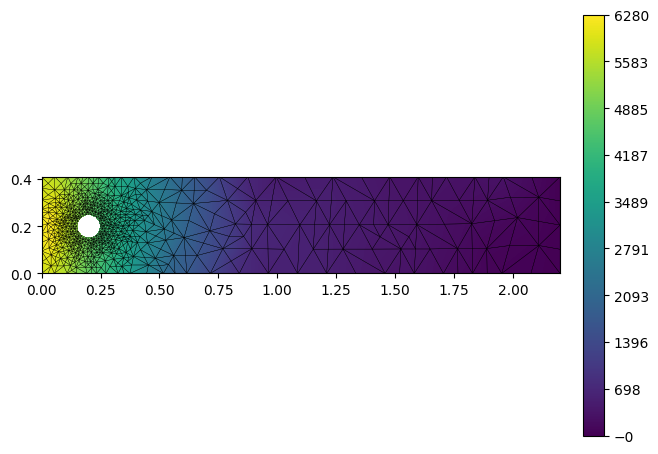

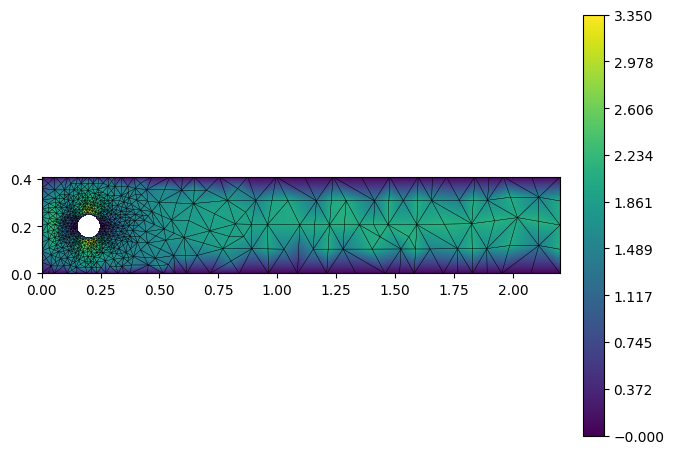

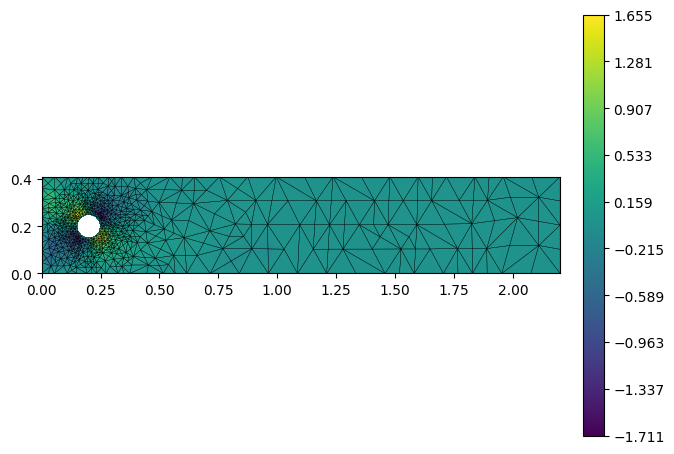

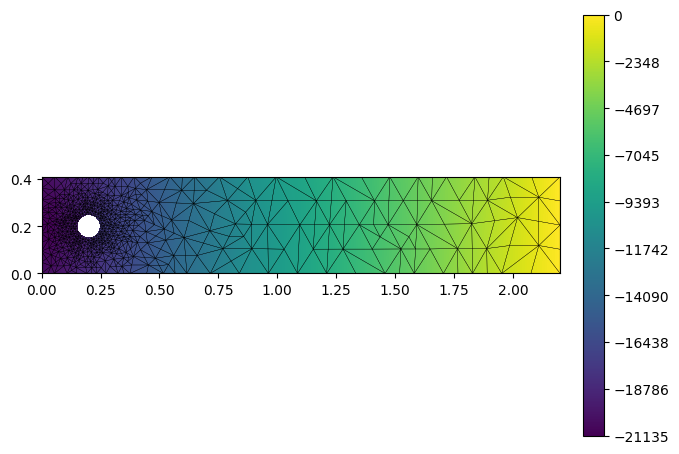

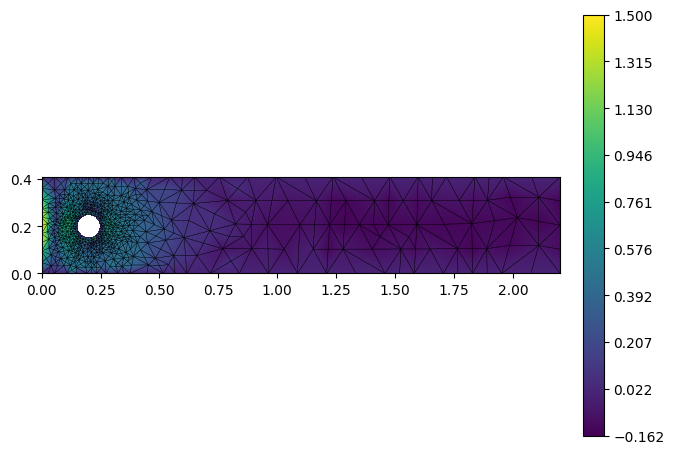

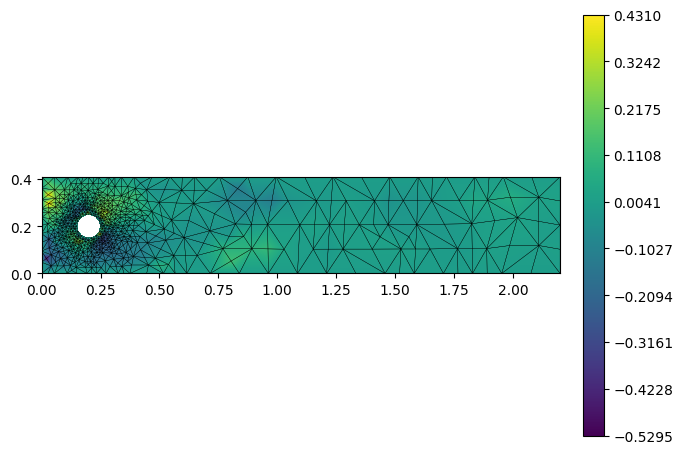

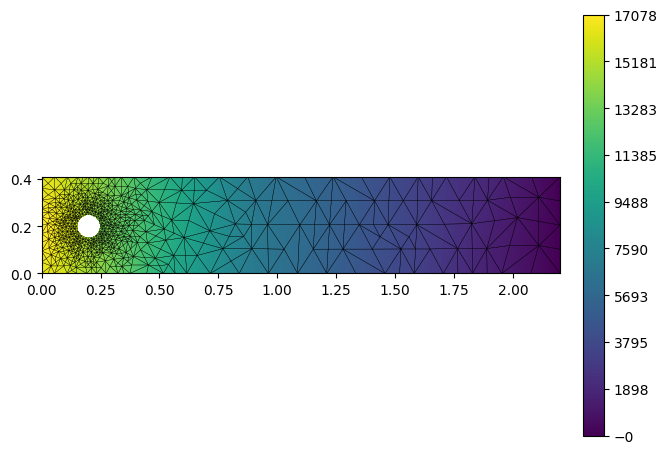

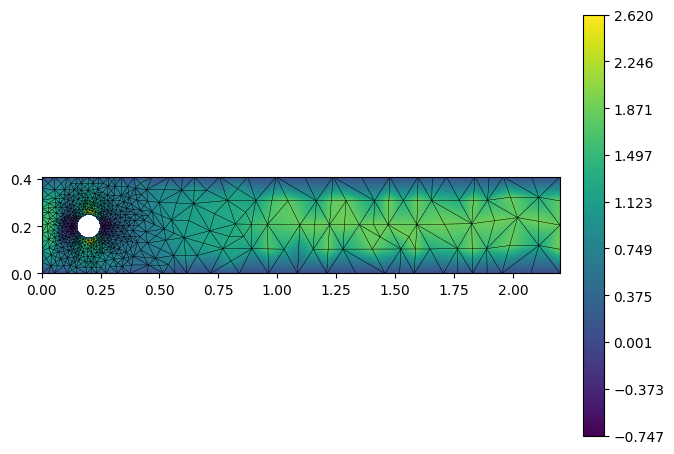

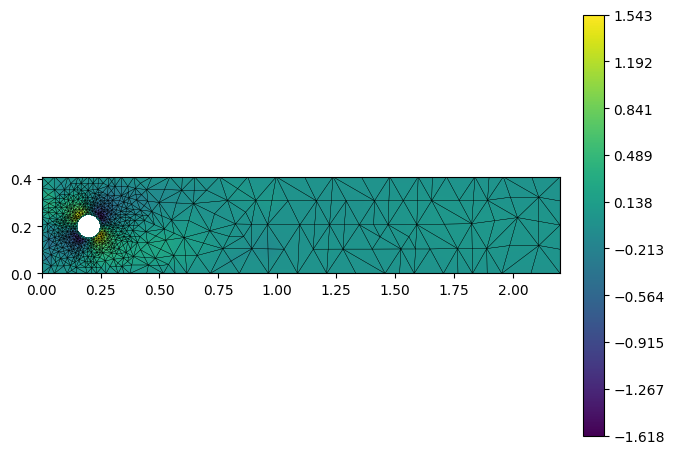

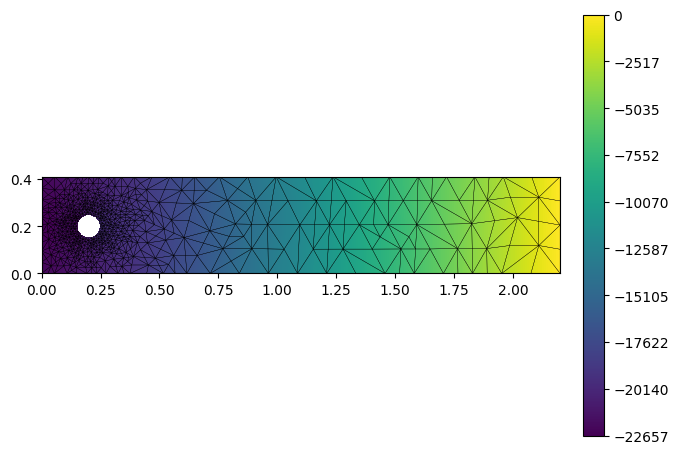

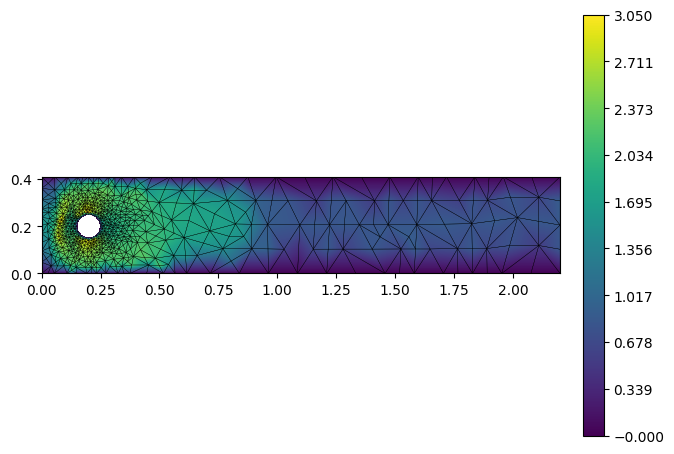

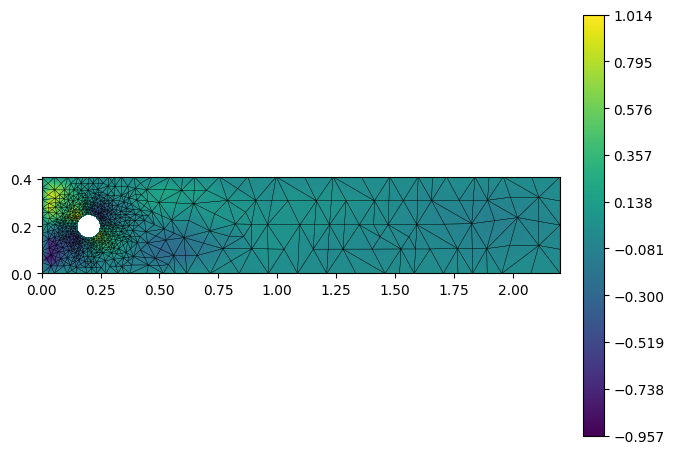

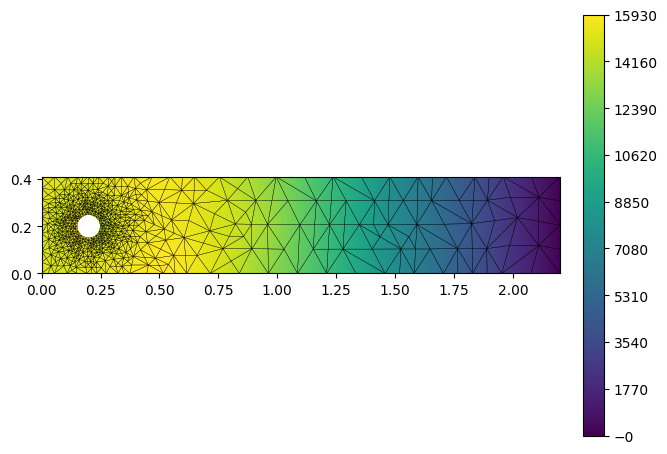

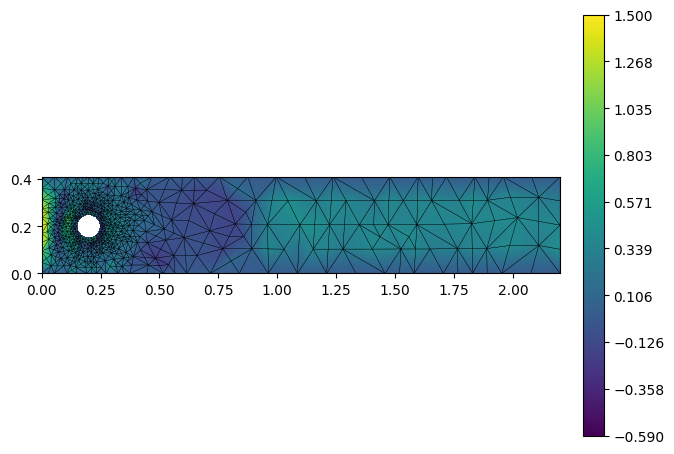

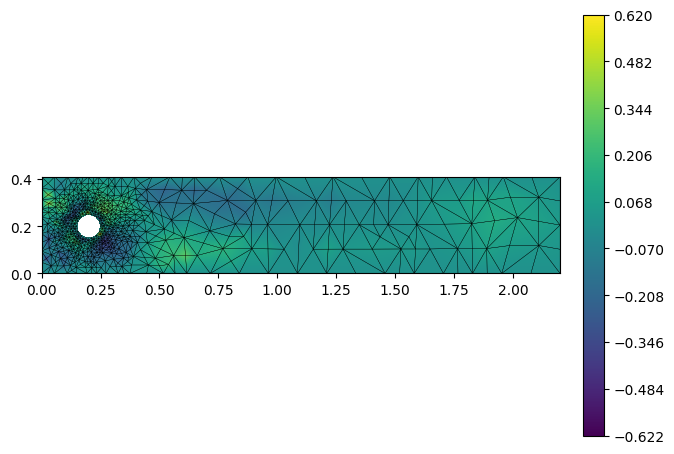

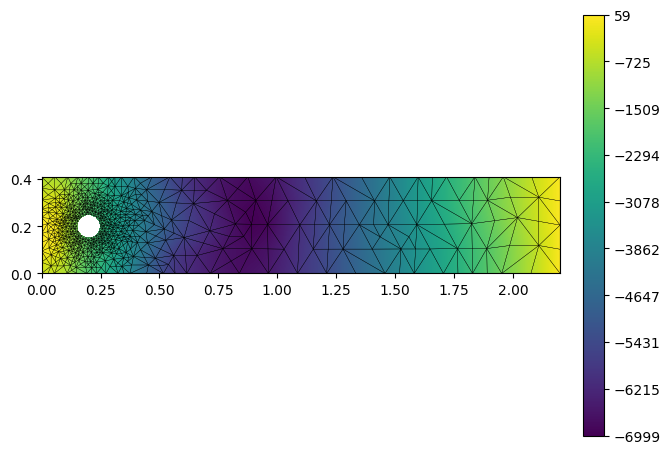

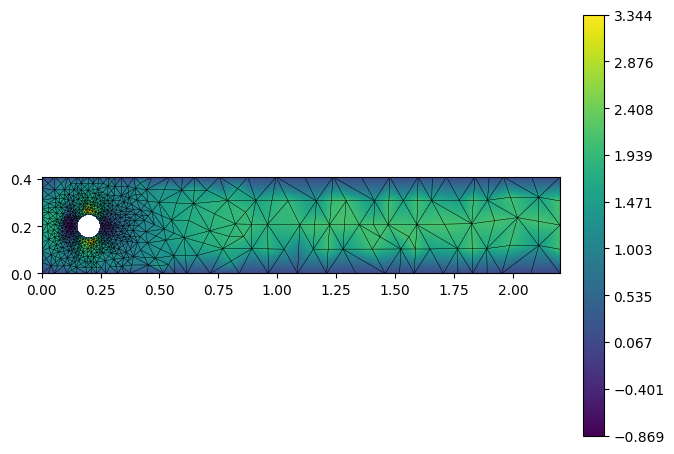

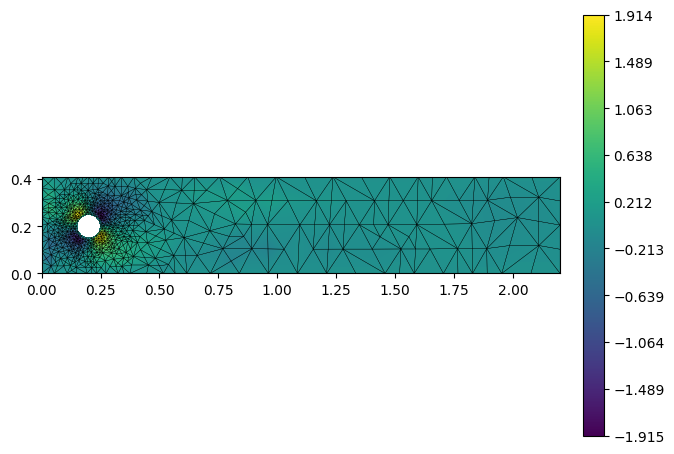

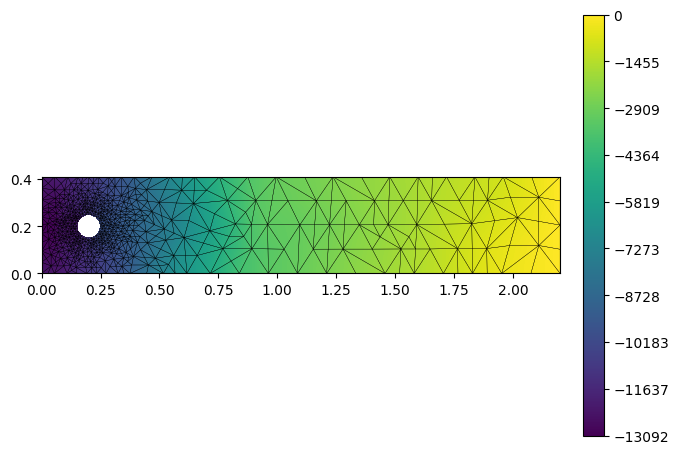

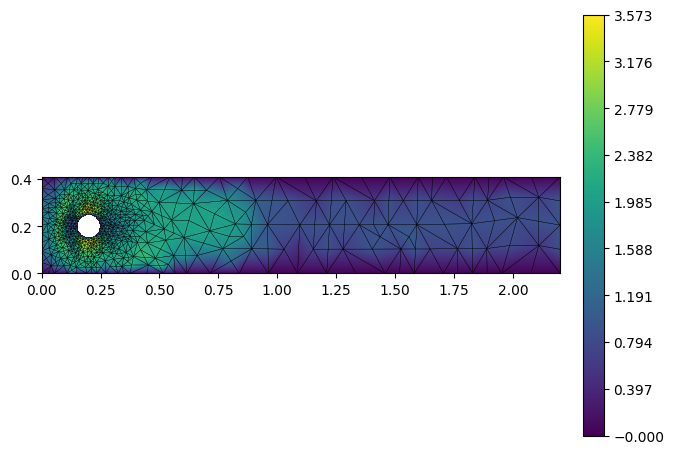

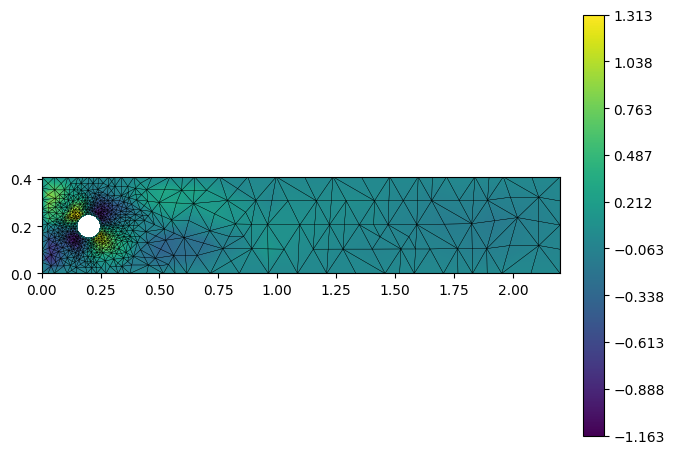

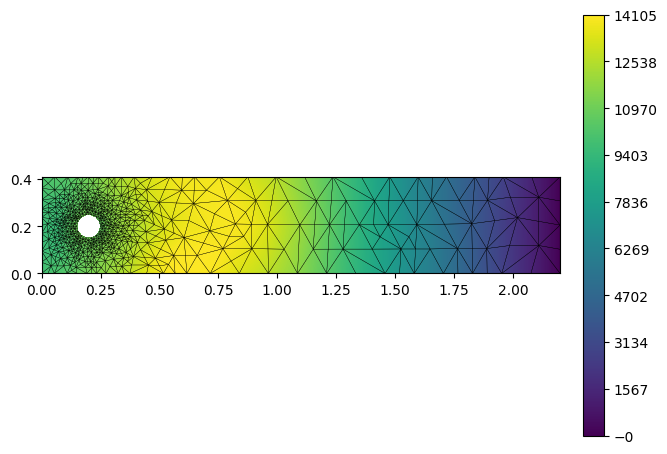

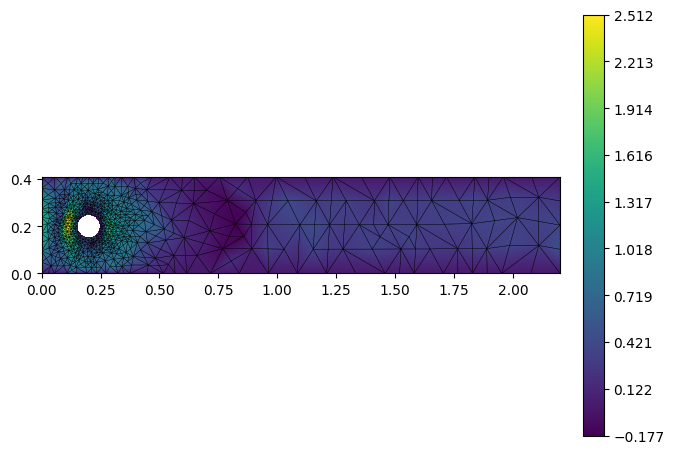

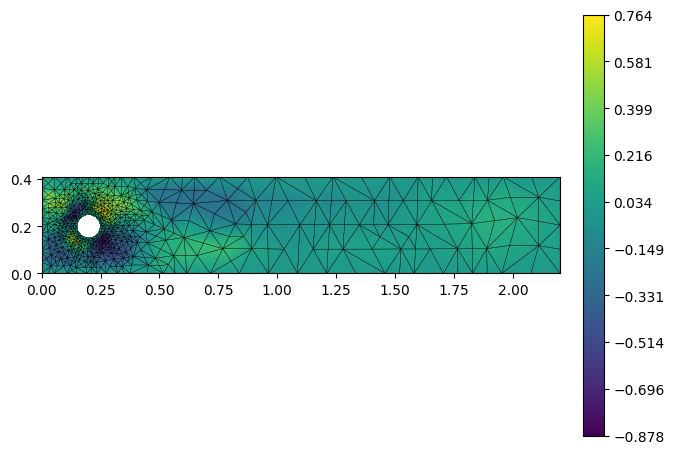

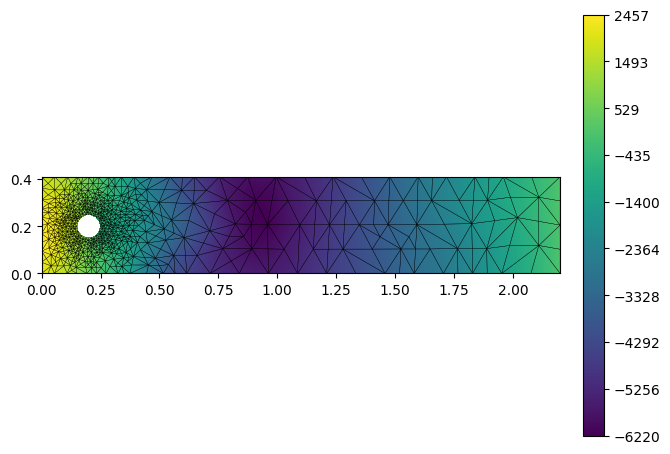

KeyboardInterrupt: 

In [10]:
velocity_history, pressure_history = vortex_solver.integrate(t_end, time_between_plots=0.001)

preconditioner: "linear.preconditioning.method":"ilu" || ""

## Task E -- Parallel implementation

Adjust your program such that it can run in parallel using MPI,
e.g. on $4$ cores (or use more, but at least more than $1$ core!) using

```
mpirun -np 4 python your_program.py
```

Please keep in mind that on your laptop parallelization may gain
little to no speedup. You will be given access to a compute-server
of the Maths department. Run speed-up tests on that server. For
meaningful results you have to control the number of threads used
for linear algebra, e.g.


In [ ]:
from dune.fem import threading
threading.use = 1
#

## Task F -- Adaptivity

Run the Karman Vortex Street example using adaptive mesh refinement
and coarsening. As an indicator use the curl of $u$ also known as
the vorticity. More precise: use the $L^2$-norm of the curl on each
element. Refine the grid, where the vorticity is high, and coarsen,
where the vorticity is low.

Consult the tutorial for the appropriate adaptivity cycle, in
particular the solution-code for the Cahn-Hilliard and Heat-Robin
examples. Both can be found in the ILIAS.


In [8]:
A = np.array([[0],[1]])
a={}
B= [0,1]
print(np.shape(A))
a[0]=B

(2, 1)


In [9]:
a

{0: [0, 1]}